# Set Up

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
import math

In [92]:
nc_file = f"../Data/sim2D2-20-pw1-v5_averages.nc"
ds_avg_flux = xr.open_dataset(nc_file).load()
case_flux = "2D2-flux"
ds_avg_flux.close()

nc_file = f"../Data/sim2D2-20_averages.nc"
ds_avg_noflux = xr.open_dataset(nc_file).load()
case = "2D2"
ds_avg_noflux.close()


image_save_folder = "flux"

In [3]:
ds_avg_flux

<xarray.Dataset> Size: 95MB
Dimensions:  (zC: 128, zF: 129, xC: 1024, yF: 1, xF: 1024, yC: 1, time: 5761)
Coordinates:
  * zC       (zC) float64 1kB -99.29 -97.88 -96.49 ... -0.9796 -0.5853 -0.1945
  * zF       (zF) float64 1kB -100.0 -98.58 -97.18 -95.8 ... -0.7815 -0.389 0.0
  * xC       (xC) float64 8kB 0.5 1.5 2.5 3.5 ... 1.022e+03 1.022e+03 1.024e+03
  * yF       (yF) float64 8B 1.0
  * xF       (xF) float64 8kB 0.0 1.0 2.0 3.0 ... 1.021e+03 1.022e+03 1.023e+03
  * yC       (yC) float64 8B 1.0
  * time     (time) timedelta64[ns] 46kB 00:00:00 00:05:00 ... 20 days 00:00:00
Data variables: (12/17)
    b        (time, zC) float64 6MB -0.008936 -0.00881 ... -0.003619 -0.003748
    fM2u     (time, zC) float64 6MB 4.584e-16 -1.573e-16 ... -1.758e-13
    M2mvtdz  (time, zF) float64 6MB 1.798e-09 1.798e-09 ... 8.745e-10 1.798e-09
    N2       (time, zF) float64 6MB 9e-05 9e-05 9e-05 ... -0.000328 0.0
    vt       (time, zC) float64 6MB 0.421 0.415 0.4091 ... 0.02128 0.02047
    fiuw′dz  (time, zF) float64 6MB 2.423e-22 -4.196e-06 ... 0.003089 2.276e-17
    ...       ...
    wbdz     (time, zC) float64 6MB 0.0 0.0 0.0 ... -2.03e-07 -3.025e-07
    fbdz     (time, zF) float64 6MB 9e-09 9e-09 9e-09 ... -3.28e-08 0.0
    uM2      (time, zC) float64 6MB 4.584e-12 -1.573e-12 ... -1.758e-09
    fivw′dz  (time, zF) float64 6MB 5.294e-06 -8.388e-07 ... -0.03794 -0.01143
    b_flux   (time) float64 46kB 2.12e-07 2.12e-07 ... 2.12e-07 2.12e-07
    u        (time, zC) float64 6MB -1.081e-05 3.711e-06 ... 0.003521 0.004147
Attributes: (12/14)
    f:                     0.0001
    schedule:              TimeInterval
    interval:              300.0
    Julia:                 This file was generated using Julia Version 1.9.2\...
    output time interval:  Output was saved every 5 minutes.
    B₀:                    -4.24e-08
    ...                    ...
    date:                  This file was generated on 2024-09-01T09:26:32.245.
    M²:                    -4.24e-07
    ν₀:                    0.0001
    Oceananigans:          This file was generated using Oceananigans v0.90.14
    N₀²:                   9e-05
    β:                     -0.09

# Buoyancy Flux

Max buoyancy flux value 2.1200000000000002e-07
Min buoyancy flux value -3.2081411404882893e-07


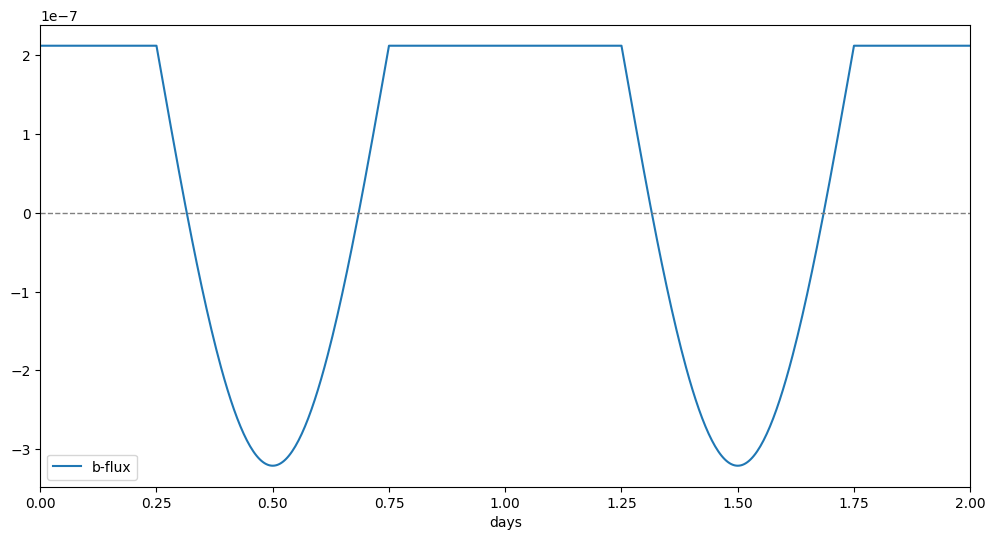

In [93]:
figs, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 6),sharex=True)
print(f'Max buoyancy flux value {ds_avg_flux.b_flux.max().values}')
print(f'Min buoyancy flux value {ds_avg_flux.b_flux.min().values}')

axes.plot(ds_avg_flux.coords['time'].values / np.timedelta64(1, 'D'), ds_avg_flux.b_flux, label="b-flux")
axes.axhline(0, color='gray', linestyle='--', linewidth=1)  # Add this line to plot y=0
axes.set_xlim(0, 2)
axes.set_xlabel("days")
axes.legend()

plt.show()

# Buoyancy Profile

## Evolution

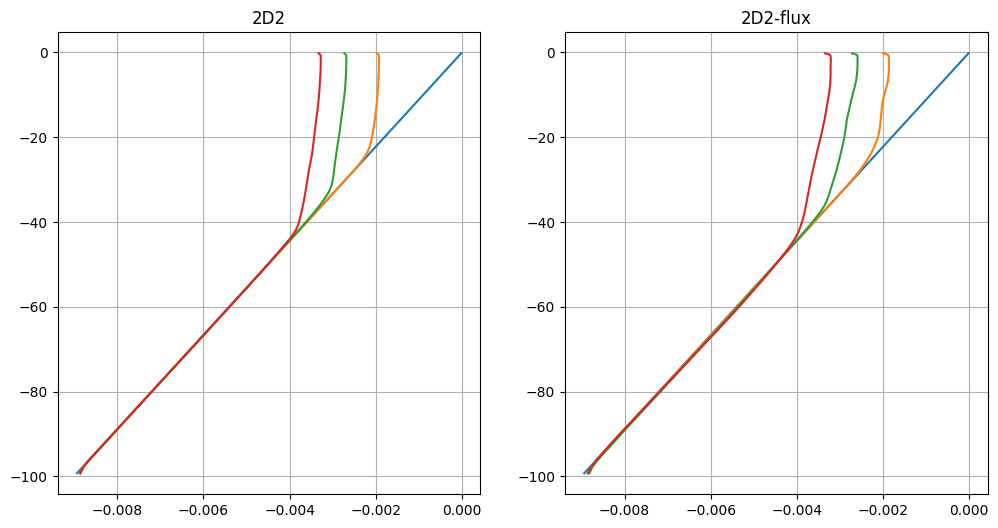

In [94]:
final_time = len(ds_avg_noflux.b)-1
middle_time = int(round((final_time) / 2))

figs, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6),sharex=True)

axe1 = axes[0]
axe2 = axes[1]
for i in range(0, final_time, round(final_time/4)):
    axe1.plot(ds_avg_noflux.b.isel(time=i).values, ds_avg_noflux.zC)
    axe2.plot(ds_avg_flux.b.isel(time=i).values,ds_avg_flux.zC)

axe1.set_title(case)
axe2.set_title(case_flux)
axe1.grid()
axe2.grid()




plt.show()

## Evolution Movie

KeyboardInterrupt: 

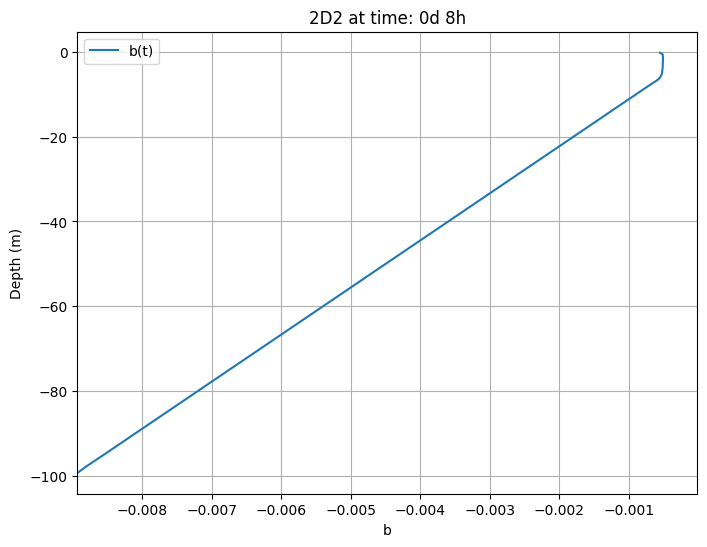

In [90]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

min_value = ds_avg_noflux.b.min()
max_value = ds_avg_noflux.b.max()

# Define a function to update the plot for each frame
def update(frame):
    ax.cla()  # Clear the current axis
    ax.plot(ds_avg_noflux.b.isel(time=frame), ds_avg_noflux.zC, label="b(t)")
    ax.set_ylabel('Depth (m)')
    ax.set_xlabel('b')
    ax.legend()
    ax.grid()
    
    # Convert time to days, hours, and minutes
    time_in_seconds = pd.to_timedelta(ds_avg_noflux.time[frame].values, unit='s')
    days = time_in_seconds.days
    hours, remainder = divmod(time_in_seconds.seconds, 3600)

    ax.set_title(f'{data_set} at time: {days}d {hours}h')
    
    ax.set_xlim(min_value, max_value)

# Create the animation object
ani = animation.FuncAnimation(fig, update, frames=len(ds_avg_noflux.time), interval=10000, repeat=False)

# Save the animation as a GIF
ani.save(f'images/buoyancy-evaluation-{data_set}.gif', writer='pillow')

# Figure 2

Evolution of the buoyancy frequency normalized by the initial value for a simulation of upright convection (simulation 2D1) and convection at a density front (simulation 2D2).

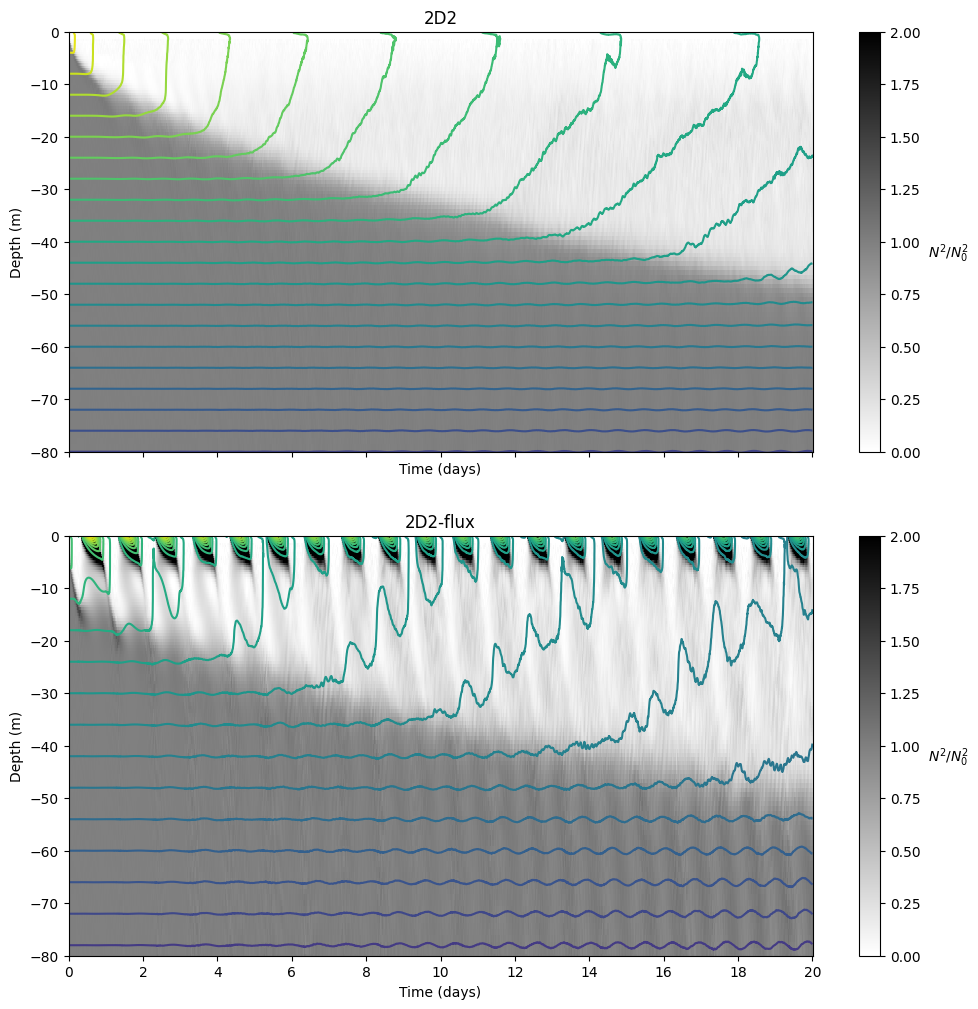

In [95]:
figure_name = "Figure 2"
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 12), sharex=True)

# Plot for ds_avg1
ax1 = axes[0]

N2_1 = ds_avg_noflux['N2']
time_1 = N2_1.coords['time'].values / np.timedelta64(1, 'D')  # Convert time to days
depth_1 = N2_1.coords['zF'].values
N2_values_1 = N2_1.values / ds_avg_noflux.attrs["N₀²"]

contourf_1 = ax1.pcolormesh(time_1, depth_1, N2_values_1.T, cmap='gray_r', vmin=0, vmax=2)
cbar_1 = plt.colorbar(contourf_1, ax=ax1)
cbar_1.set_label(r'$N^2 / N_0^2$', rotation=0, labelpad=20)

contour_1 = ax1.contour(time_1, ds_avg_noflux.b.zC, ds_avg_noflux.b[:, :].T / ds_avg_noflux.attrs["N₀²"], levels=25, cmap='viridis')

ax1.set_title(case)
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Depth (m)')
ax1.set_ylim(-80, 0)

# Set x-axis ticks to increments of 2 days
time_min = np.floor(time_1.min())
time_max = np.ceil(time_1.max())
ax1.set_xticks(np.arange(time_min, time_max + 2, 2))

# Plot for ds_avg2
ax2 = axes[1]
N2_2 = ds_avg_flux['N2']
time_2 = N2_2.coords['time'].values / np.timedelta64(1, 'D')  # Convert time to days
depth_2 = N2_2.coords['zF'].values
N2_values_2 = N2_2.values / ds_avg_flux.attrs["N₀²"]

contourf_2 = ax2.pcolormesh(time_2, depth_2, N2_values_2.T, vmin=0, vmax=2, cmap='gray_r')
cbar_2 = plt.colorbar(contourf_2, ax=ax2)
cbar_2.set_label(r'$N^2 / N_0^2$', rotation=0, labelpad=20)

contour_2 = ax2.contour(time_2, ds_avg_flux.b.zC, ds_avg_flux.b[:, :].T / ds_avg_flux.attrs["N₀²"], levels=25, cmap='viridis')

ax2.set_title(case_flux)
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Depth (m)')
ax2.set_ylim(-80, 0)

# Set x-axis ticks to increments of 2 days
time_min = np.floor(time_2.min())
time_max = np.ceil(time_2.max())
ax2.set_xticks(np.arange(time_min, time_max + 2, 2))

# Save the figure
plt.savefig(f"images/{image_save_folder}{figure_name}.png", dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

#  Buoyancy frequency and bulk Richardson 

## Figure 3

In [12]:
inertial_period = (2*math.pi)/ds_avg_noflux.attrs['f']

(a) Buoyancy frequency and (b) bulk Richardson number averaged in $x$ and for $1$ day centered at $t = 15$ days.

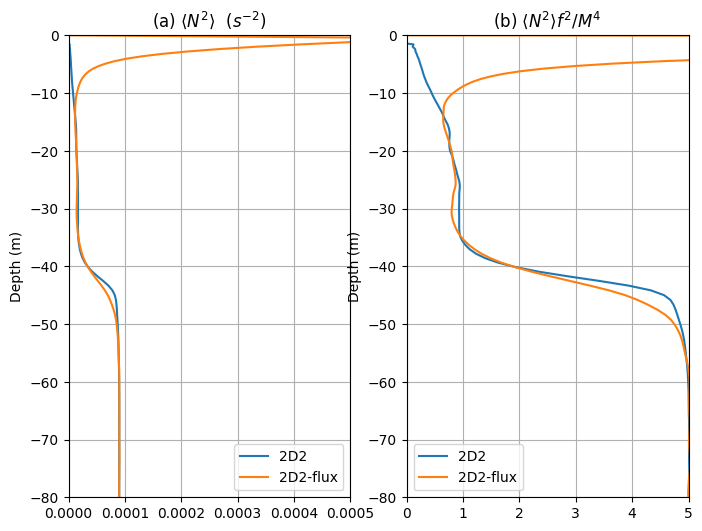

In [99]:
# Compute the mean of one inertial period centered at day 15
inertial_period_days = 2 * (inertial_period / (24 * 3600))
# inertial_period_days = (24 * 3600)

center_day = 15
start_day = center_day - inertial_period_days / 2
end_day = center_day + inertial_period_days / 2


# Plot the results
fig, axs = plt.subplots(ncols=2, nrows = 1, figsize=(8, 6))


ax = axs[0]

time_in_days = ds_avg_noflux['time'].values / np.timedelta64(1, 'D')
time_mask = (time_in_days >= start_day) & (time_in_days <= end_day)
ds_selected = ds_avg_noflux.N2.isel(time=time_mask)
ds_mean = ds_selected.mean(dim='time')
ax.plot(ds_mean, ds_avg_noflux.zF, label=case)

time_in_days = ds_avg_flux['time'].values / np.timedelta64(1, 'D')
time_mask = (time_in_days >= start_day) & (time_in_days <= end_day)
ds_selected = ds_avg_flux.N2.isel(time=time_mask)
ds_mean = ds_selected.mean(dim='time')
ax.plot(ds_mean, ds_avg_flux.zF, label=case_flux)


ax.set_ylabel('Depth (m)')
ax.legend()
ax.set_title(f"(a) $\\left\\langle N^2 \\right\\rangle ~~ (s^{{-2}})$")
ax.grid()
ax.set_ylim(-80, 0)
ax.set_xlim(0,5e-4)


ax = axs[1]
time_in_days = ds_avg_noflux['time'].values / np.timedelta64(1, 'D')
time_mask = (time_in_days >= start_day) & (time_in_days <= end_day)
ds_selected = ds_avg_noflux.N2.isel(time=time_mask)
ds_mean = ds_selected.mean(dim='time')
ax.plot(ds_mean * (ds_avg_noflux.attrs["f"]/ds_avg_noflux.attrs["M²"])**2, ds_avg_noflux.zF, label=case)

time_in_days = ds_avg_flux['time'].values / np.timedelta64(1, 'D')
time_mask = (time_in_days >= start_day) & (time_in_days <= end_day)
ds_selected = ds_avg_flux.N2.isel(time=time_mask)
ds_mean = ds_selected.mean(dim='time')
ax.plot(ds_mean * (ds_avg_flux.attrs["f"]/ds_avg_flux.attrs["M²"])**2, ds_avg_flux.zF, label=case_flux)

ax.set_ylabel('Depth (m)')
ax.legend()
ax.set_title(f"(b) $\\left\\langle N^2 \\right\\rangle f^2/M^4$")
ax.grid()
ax.set_ylim(-80, 0)
ax.set_xlim(0,5)

plt.savefig(f"images/{image_save_folder}{figure_name}.png", dpi=300, bbox_inches='tight')
plt.show()

## Buoyancy Frequency Evolution Movie

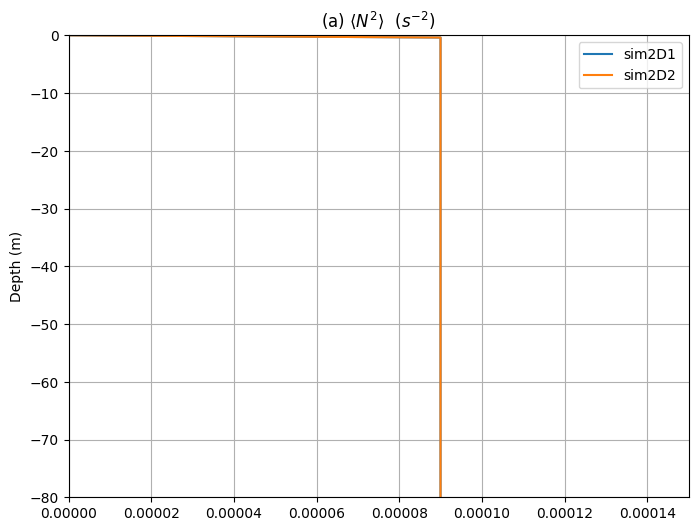

In [173]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Define a function to update the plot for each frame
def update(frame):
    ax.cla()  # Clear the current axis
    for i in range(0,num_simulations):
        ds_avg = ncs[i]
        ax.plot(ds_avg.N2.isel(time=frame), ds_avg.zF, label=f"{cases[i]}")
    
    # Convert time to days, hours, and minutes
    time_in_seconds = pd.to_timedelta(ds_avg.time[frame].values, unit='s')
    days = time_in_seconds.days
    hours, remainder = divmod(time_in_seconds.seconds, 3600)

    ax.set_ylabel('Depth (m)')
    ax.legend()
    ax.set_title(f"(a) $\\left\\langle N^2 \\right\\rangle ~~ (s^{{-2}})$ at time: {days}d {hours}h")
    ax.grid()
    ax.set_ylim(-80, 0)
    ax.set_xlim(0,15e-5)

# Create the animation object
ani = animation.FuncAnimation(fig, update, frames=len(ds_avg.time), interval=100, repeat=False)

# Save the animation as a GIF
ani.save(f'images/buoyancy-frequency-evaluation.gif', writer='pillow')

# Mean Buoyancy Budget

In [39]:
data_set1 = case
ds_avg1 = ds_avg_noflux

print(f"Using data set: {data_set1}")

data_set2 = case_flux
ds_avg2 = ds_avg_flux

print(f"Using data set: {data_set2}")

figure_name = "Figure 4"

Using data set: 2D2
Using data set: 2D2-flux


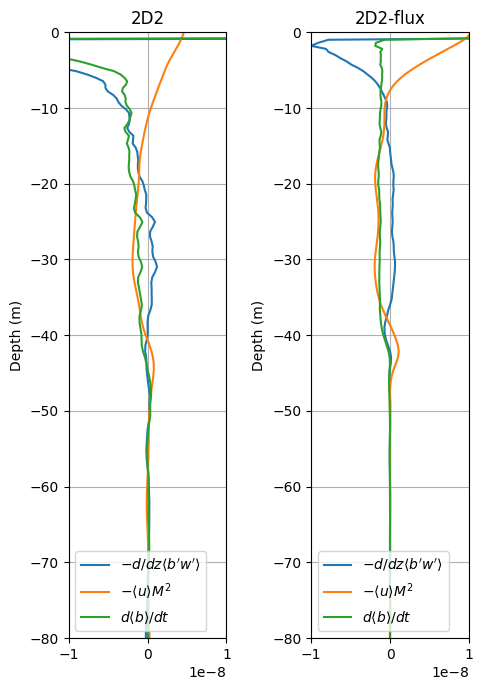

In [102]:
# Compute the mask for one inertial period centered at day 15
inertial_period_days = inertial_period / (24 * 3600)    # convert to days
# inertial_period_days = (24 * 3600)


center_day = 15
start_day = center_day - inertial_period_days / 2
end_day = center_day + inertial_period_days / 2
time_in_days = ds_avg1['time'].values / np.timedelta64(1, 'D')

time_mask = (time_in_days >= start_day) & (time_in_days <= end_day)

ds_selected_wbdz1 = ds_avg1.wbdz.sel(time=time_mask)
ds_mean_wbdz1 = ds_selected_wbdz1.mean(dim='time')

ds_selected_uM21 = ds_avg1.uM2.sel(time=time_mask)
ds_mean_uM21 = ds_selected_uM21.mean(dim='time')

ds_selected_bdt1 = - ds_avg1.wbdz.sel(time=time_mask) - ds_avg1.uM2.sel(time=time_mask) + ds_avg1.κbdz2.sel(time=time_mask)
ds_mean_bdt1 = ds_selected_bdt1.mean(dim='time')

ds_selected_wbdz2 = ds_avg2.wbdz.sel(time=time_mask)
ds_mean_wbdz2 = ds_selected_wbdz2.mean(dim='time')

ds_selected_uM22 = ds_avg2.uM2.sel(time=time_mask)
ds_mean_uM22 = ds_selected_uM22.mean(dim='time')

ds_selected_bdt2 = - ds_avg2.wbdz.sel(time=time_mask) - ds_avg2.uM2.sel(time=time_mask) + ds_avg2.κbdz2.sel(time=time_mask)
ds_mean_bdt2 = ds_selected_bdt2.mean(dim='time')


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5, 7)) 
# plotting <u>
ax1 = axes[0]
ax1.plot(-ds_mean_wbdz1, ds_avg1.zC, label="$-d/dz \\langle b'w' \\rangle$")
ax1.plot(-ds_mean_uM21, ds_avg1.zC, label="$-\\langle u \\rangle M^2$")
ax1.plot(ds_mean_bdt1, ds_avg1.zC, label="$d\\langle b \\rangle / dt$")
ax1.set_ylabel('Depth (m)')
ax1.set_ylim(-80, 0)
ax1.legend()
ax1.set_title(f"{data_set1}")
ax1.set_xlim(-1e-8,1e-8)
ax1.grid()

# plotting <v>
ax2 = axes[1]
ax2.plot(-ds_mean_wbdz2, ds_avg1.zC, label="$-d/dz \\langle b'w' \\rangle$")
ax2.plot(-ds_mean_uM22, ds_avg1.zC, label="$-\\langle u \\rangle M^2$")
ax2.plot(ds_mean_bdt2, ds_avg1.zC, label="$d\\langle b \\rangle / dt$")
ax2.set_ylabel('Depth (m)')
ax2.set_ylim(-80, 0)
ax2.legend()
ax2.set_xlim(-1e-8,1e-8)
ax2.set_title(f"{data_set2}")
ax2.grid()


plt.tight_layout()
plt.savefig(f"images/{image_save_folder}{figure_name}.png", dpi=300, bbox_inches='tight')
plt.show()

# Mean Velocities and Turbulent Ekman Balance

$$\begin{align*} f\langle u \rangle &\backsimeq - \frac{\partial \langle v^\prime w^\prime \rangle}{\partial z} + \nu \frac{\partial^2 \langle v \rangle}{\partial z^2} \\ -f\langle v \rangle &\backsimeq - \frac{\partial \langle u^\prime w^\prime \rangle}{\partial z} + \nu \frac{\partial^2 \langle u \rangle}{\partial z^2} \end{align*}$$

## Figure 5

Simulation 2D2: (a) Mean cross-front velocity, (b) mean alongfront velocity, and (c) hodograph of the mean velocity vectors (all m s−1). All quantities are averaged in x and for 1 inertial period centered at t = 15 days.

In [48]:
data_set = case_flux
ds_avg = ds_avg_flux

print(f"Using data set: {data_set}")

figure_name = "Figure 5"

Using data set: 2D2-flux


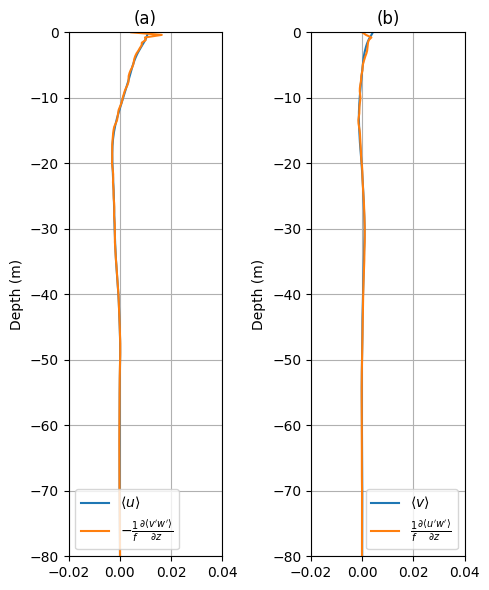

In [49]:
# Compute the mask for one inertial period centered at day 15
# inertial_period_days = inertial_period / (24 * 3600)    # convert to days
inertial_period_days = (24 * 3600)


center_day = 15
start_day = center_day - inertial_period_days / 2
end_day = center_day + inertial_period_days / 2
time_in_days = ds_avg['time'].values / np.timedelta64(1, 'D')

time_mask = (time_in_days >= start_day) & (time_in_days <= end_day)

ds_selected_u = ds_avg.u.sel(time=time_mask)
ds_mean_u = ds_selected_u.mean(dim='time')

ds_selected_fivw = ds_avg['fivw′dz'].sel(time=time_mask)
ds_mean_fivw = ds_avg['fivw′dz'].mean(dim='time')


ds_selected_v = ds_avg.v.sel(time=time_mask)
ds_mean_v = ds_selected_v.mean(dim='time')

ds_selected_fiuw = ds_avg['fiuw′dz'].sel(time=time_mask)
ds_mean_fiuw = ds_avg['fiuw′dz'].mean(dim='time')

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5, 6), sharex=True) 
# plotting <u>
ax1 = axes[0]
ax1.plot(ds_mean_u, ds_avg.zC, label="$\\langle u \\rangle$")
ax1.plot(-ds_mean_fivw, ds_mean_fivw.zF, label="$-\\frac{1}{f}\\frac{\\partial \\langle v' w' \\rangle}{\\partial z}$")
ax1.set_ylabel('Depth (m)')
ax1.set_ylim(-80, 0)
ax1.set_xlim(-0.02, 0.04)
ax1.legend()
ax1.set_title("(a)")
ax1.grid()

# plotting <v>
ax2 = axes[1]
ax2.plot(ds_mean_v, ds_avg.zC, label="$\\langle v \\rangle$")
ax2.plot(ds_mean_fiuw, ds_mean_fiuw.zF, label="$\\frac{1}{f}\\frac{\\partial \\langle u' w' \\rangle}{\\partial z}$")
ax2.set_ylabel('Depth (m)')
ax2.set_ylim(-80, 0)
ax1.set_xlim(-0.02, 0.04)
ax2.legend()
ax2.set_title("(b)")
ax2.grid()


plt.tight_layout()
plt.savefig(f"images/{image_save_folder}{figure_name}-ab.png", dpi=300, bbox_inches='tight')
plt.show()

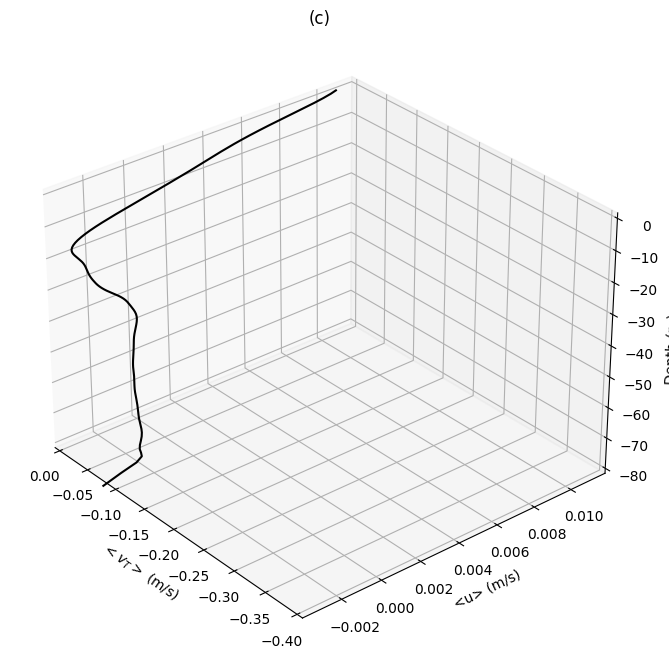

In [45]:
fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection='3d')

ds_selected_vt = ds_avg.vt.sel(time=time_mask)
ds_mean_vt = ds_selected_vt.mean(dim='time')

ax.plot(ds_mean_v,ds_mean_u, ds_avg.zC, color='black')

ax.set_ylabel('<u> (m/s)')
ax.set_xlabel(r'$<v_{T}>$ (m/s)')
ax.set_zlabel('Depth (m)')
ax.set_zlim(-80, 0)
ax.set_xlim(0,-0.4)
ax.set_title("(c)")
ax.view_init(elev=30, azim=-40)

plt.savefig(f"images/{image_save_folder}{figure_name}-c.png", dpi=300, bbox_inches='tight')
plt.show()

## Mean Velocities Evolution Movie

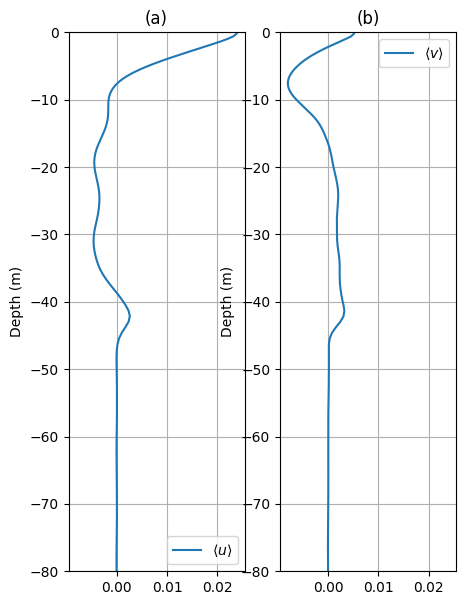

In [149]:
# Create a figure and axis
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5, 7), sharex=True) 

# Define a function to update the plot for each frame
def update(frame):
    # plotting <u>
    ax1 = axes[0]
    ax1.cla()  # Clear the current axis
    ax1.plot(ds_mean_u, ds_avg.zC, label="$\langle u \\rangle$")
    ax1.set_ylabel('Depth (m)')
    ax1.set_ylim(-80, 0)
    ax1.legend()
    ax1.set_title("(a)")
    ax1.grid()

    # plotting <v>
    ax2 = axes[1]
    ax2.cla()  # Clear the current axis    
    ax2.plot(ds_mean_v, ds_avg.zC, label="$\langle v \\rangle$")
    ax2.set_ylabel('Depth (m)')
    ax2.set_ylim(-80, 0)
    ax2.legend()
    ax2.set_title("(b)")
    ax2.grid()
    
    # Convert time to days, hours, and minutes
    time_in_seconds = pd.to_timedelta(ds_avg.time[frame].values, unit='s')
    days = time_in_seconds.days
    hours, remainder = divmod(time_in_seconds.seconds, 3600)

    # fig.title(f"t = {days}d {hours}h")

# Create the animation object
ani = animation.FuncAnimation(fig, update, frames=len(ds_avg.time), interval=100, repeat=False)

# Save the animation as a GIF
ani.save(f'images/mean-velocity-evaluation.gif', writer='pillow')

# Mean PV

$$\langle q \rangle = f \frac{\partial \langle b \rangle}{\partial z} + \frac{\partial}{\partial z}\langle \zeta^\prime b^\prime \rangle - M^2 \frac{\partial \langle v_T \rangle}{\partial z}

## Profiles

mean PV at $t=10$ days, $x$-averaged and averaged over one inertial period

In [50]:
data_set_1 = case
ds_avg_1 = ds_avg

print(f"Using data set: {data_set_1}")

data_set_2 = case_flux
ds_avg_2 = ds_avg_flux

print(f"Using data set: {data_set_2}")

figure_name = "Figure 13"

Using data set: 2D2
Using data set: 2D2-flux


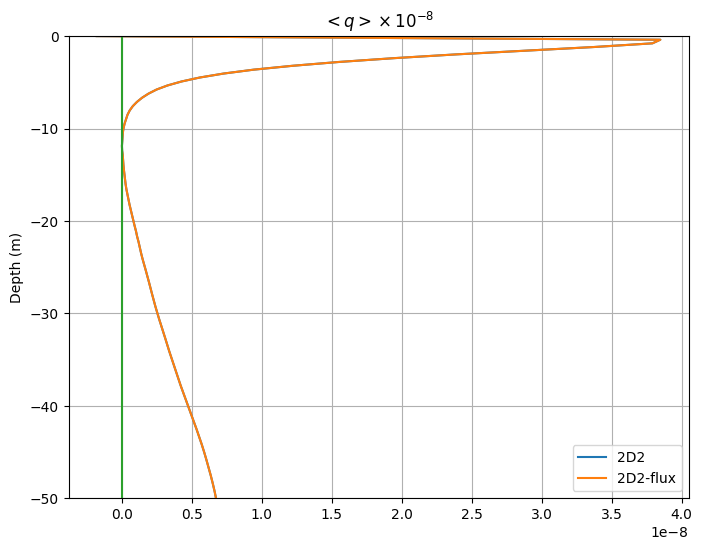

In [51]:
ds_q_avg_1 = ds_avg_1.fbdz + ds_avg_1["ζb′"] - ds_avg_1.M2mvtdz 
ds_q_avg_2 = ds_avg_2.fbdz + ds_avg_2["ζb′"] - ds_avg_2.M2mvtdz 

time_1 = ds_q_avg_1.coords['time'].values / np.timedelta64(1, 'D')  # Convert time to days
time_2 = ds_q_avg_2.coords['time'].values / np.timedelta64(1, 'D')  # Convert time to days

center_day = 10
start_day = center_day - inertial_period_days / 2
end_day = center_day + inertial_period_days / 2
time_in_days_1 = ds_avg_1['time'].values / np.timedelta64(1, 'D')
time_in_days_2 = ds_avg_2['time'].values / np.timedelta64(1, 'D')

time_mask_1 = (time_in_days_1 >= start_day) & (time_in_days_1 <= end_day)
time_mask_2 = (time_in_days_2 >= start_day) & (time_in_days_2 <= end_day)

ds_selected_q_1 = ds_q_avg_1.sel(time=time_mask_1)
ds_selected_q_2 = ds_q_avg_2.sel(time=time_mask_2)
ds_mean_q_1 = ds_selected_q_1.mean(dim='time')
ds_mean_q_2 = ds_selected_q_2.mean(dim='time')

plt.figure(figsize=(8, 6))
plt.plot(ds_mean_q_1, ds_avg_1.zF, label=f"{data_set_1}")
plt.plot(ds_mean_q_2, ds_avg_2.zF, label=f"{data_set_2}")
plt.plot(np.zeros(len(ds_avg_2.zF)), ds_avg_2.zF)
plt.title(f"$<q> \\times 10^{{-8}}$")
plt.ylim(-50,0)
plt.ylabel('Depth (m)')
plt.legend()
plt.grid()
plt.savefig(f"images/{image_save_folder}{figure_name}.png", dpi=300, bbox_inches='tight')
plt.show()

## Contour Plots

Integrating Equation (23) yields $$H(t) = \left[ H_0^2 + \frac{2ft}{fN_0^2 - M^4/f}(1 + \alpha + \beta)(B_0 - \frac{\tau_y^w M^2}{\rho_0 f})\right]^{{1/2}}.$$ Since we are considering the case where $\tau_y^w=0$ we can simplify this to $$H(t) = \left[ H_0^2 + \frac{2ftB_0}{fN_0^2 - M^4/f}(1 + \alpha + \beta)\right]^{{1/2}}$$ where $H_0$ is the low PV layer depth at $t=0$: Would this just be zero and thus  $$H_0^2 = \left[ \frac{2f \cdot 0 \cdot B_0}{fN_0^2 - M^4/f}(1 + \alpha + \beta)\right]^{{1/2}} = 0.$$ Therefore, we can predict the low PV layer depth using $$H(t) = \left[\frac{2ftB_0}{fN_0^2 - M^4/f}(1 + \alpha + \beta)\right]^{{1/2}}$$ I think having $H_0 = 0$ may be incorrect since the square root is having negative values. For now, let's just use `abs()` around the inner function being square rooted $$H(t) = \left| \frac{2ftB_0}{fN_0^2 - M^4/f}(1 + \alpha + \beta)\right|^{{1/2}}$$

In [52]:
num_simulations = [0,1,2,3,4,5]
# num_simulations = [0]

figure_name = "Figure 7-9"

In [53]:
sim_attributes = {
    'M²': ds_avg_flux.attrs["M²"],
    'B₀': ds_avg_flux.attrs["B₀"],
    'α': ds_avg_flux.attrs["α"],
    'β': ds_avg_flux.attrs["β"],
    'N₀²' : ds_avg_flux.attrs['N₀²'],
    'f' : ds_avg_flux.attrs['f']
}

In [54]:
#TODO: FIX ME 
def predicted_PV_depth(t,i,ds_avg):
    f = ds_avg_flux.attrs['f']
    N02 = ds_avg_flux.attrs['N₀²']
    M2 = ds_avg_flux.attrs["M²"]
    B0 = ds_avg_flux.attrs["B₀"]
    alpha = ds_avg_flux.attrs["α"]
    beta = ds_avg_flux.attrs["β"]

    inner1 = 2*f*t*B0 / (f * N02**2 - (M2 ** 2 / f))
    inner2 = (1 + alpha + beta)
    return (abs(inner1 * inner2))**(1/2)

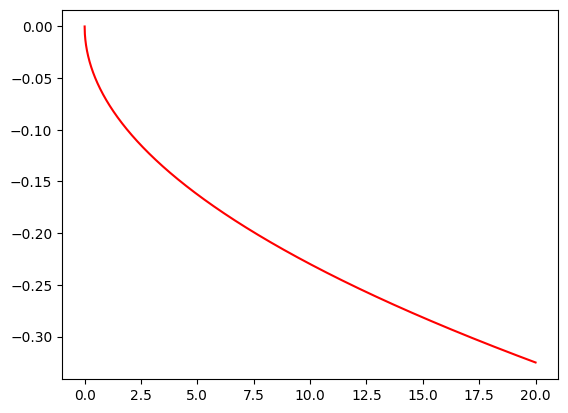

In [55]:
ds_avg = ds_avg_flux
ds_q_avg = ds_avg.fbdz + ds_avg["ζb′"] - ds_avg.M2mvtdz 
time_values = ds_q_avg.coords["time"].values / np.timedelta64(1, 'D')  # Convert time to days
predicted_depth = predicted_PV_depth(time_values, 0, ds_avg)
plt.plot(time_values, -1 * predicted_depth, color='red', label='Predicted PV Depth')

In [70]:
ds_avg1 = ds_avg_flux
ds_q_avg = ds_avg1.fbdz + ds_avg1["ζb′"] - ds_avg1.M2mvtdz 


ds_avg2 = ds_avg_noflux
ds_q_avg = ds_avg2.fbdz + ds_avg2["ζb′"] - ds_avg2.M2mvtdz 


# print(ds_avg1.fbdz)
# print(ds_avg2.fbdz)

print((abs(ds_avg1.fbdz - ds_avg2.fbdz)).max().values)
print((abs(ds_avg1["ζb′"] - ds_avg2["ζb′"])).max().values)
print((abs(ds_avg1.M2mvtdz - ds_avg2.M2mvtdz)).max().values)

2.3776458089439606e-07
9.527638013815494e-08
7.115939355143033e-09


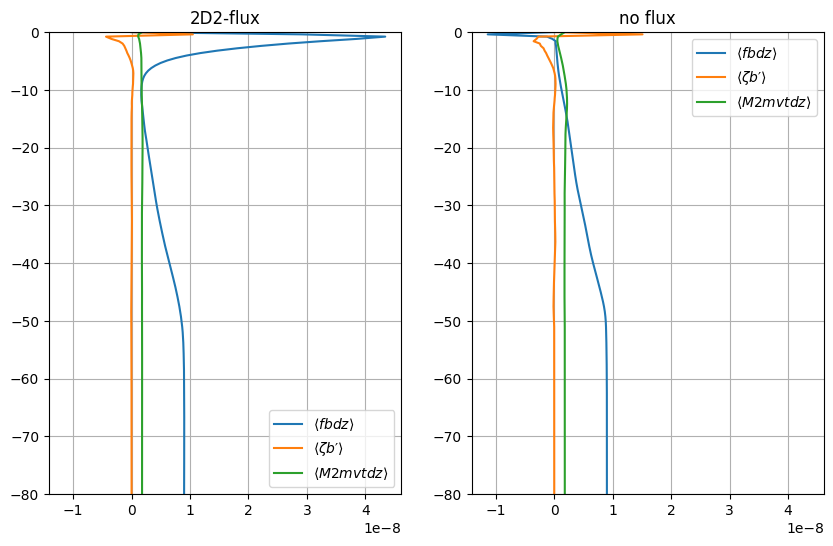

In [85]:
# inertial_period_days = inertial_period / (24 * 3600)    # convert to days
inertial_period_days = (24 * 3600)

ds_avg = ds_avg_flux
data_set = case_flux

center_day = 15
start_day = center_day - inertial_period_days / 2
end_day = center_day + inertial_period_days / 2
time_in_days = ds_avg['time'].values / np.timedelta64(1, 'D')

time_mask = (time_in_days >= start_day) & (time_in_days <= end_day)

ds_selected_fbdz = ds_avg.fbdz.sel(time=time_mask)
ds_mean_fbdz = ds_selected_fbdz.mean(dim='time')

ds_selected_cb = ds_avg['ζb′'].sel(time=time_mask)
ds_mean_cb = ds_avg['ζb′'].mean(dim='time')

ds_selected_M2mvtdz = ds_avg.M2mvtdz.sel(time=time_mask)
ds_mean_M2mvtdz = ds_selected_M2mvtdz.mean(dim='time')


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6), sharex=True) 
# plotting <u>
ax1 = axes[0]
ax1.plot(ds_mean_fbdz, ds_avg.zF, label="$\\langle fbdz \\rangle$")
ax1.plot(ds_mean_cb, ds_avg.zF, label="$\\langle ζb′ \\rangle$")
ax1.plot(ds_mean_M2mvtdz, ds_avg.zF, label="$\\langle M2mvtdz \\rangle$")
# ax1.plot(-ds_mean_fivw, ds_mean_fivw.zF, label="$-\\frac{1}{f}\\frac{\\partial \\langle v' w' \\rangle}{\\partial z}$")
# ax1.set_ylabel('Depth (m)')
ax1.set_ylim(-80, 0)
# # ax1.set_xlim(-0.02, 0.04)
ax1.legend()
ax1.set_title(data_set)
ax1.grid()


ds_avg = ds_avg_noflux

center_day = 15
start_day = center_day - inertial_period_days / 2
end_day = center_day + inertial_period_days / 2
time_in_days = ds_avg['time'].values / np.timedelta64(1, 'D')

time_mask = (time_in_days >= start_day) & (time_in_days <= end_day)

ds_selected_fbdz = ds_avg.fbdz.sel(time=time_mask)
ds_mean_fbdz = ds_selected_fbdz.mean(dim='time')

ds_selected_cb = ds_avg['ζb′'].sel(time=time_mask)
ds_mean_cb = ds_avg['ζb′'].mean(dim='time')

ds_selected_M2mvtdz = ds_avg.M2mvtdz.sel(time=time_mask)
ds_mean_M2mvtdz = ds_selected_M2mvtdz.mean(dim='time')

ax1 = axes[1]
ax1.plot(ds_mean_fbdz, ds_avg.zF, label="$\\langle fbdz \\rangle$")
ax1.plot(ds_mean_cb, ds_avg.zF, label="$\\langle ζb′ \\rangle$")
ax1.plot(ds_mean_M2mvtdz, ds_avg.zF, label="$\\langle M2mvtdz \\rangle$")

ax1.set_ylim(-80, 0)
# # ax1.set_xlim(-0.02, 0.04)
ax1.legend()
ax1.set_title("no flux")
ax1.grid()
# # plotting <v>
# ax2 = axes[1]
# ax2.plot(ds_mean_v, ds_avg.zF, label="$\\langle v \\rangle$")
# ax2.plot(ds_mean_fiuw, ds_mean_fiuw.zF, label="$\\frac{1}{f}\\frac{\\partial \\langle u' w' \\rangle}{\\partial z}$")
# ax2.set_ylabel('Depth (m)')
# ax2.set_ylim(-80, 0)
# ax1.set_xlim(-0.02, 0.04)
# ax2.legend()
# ax2.set_title("(b)")
# ax2.grid()

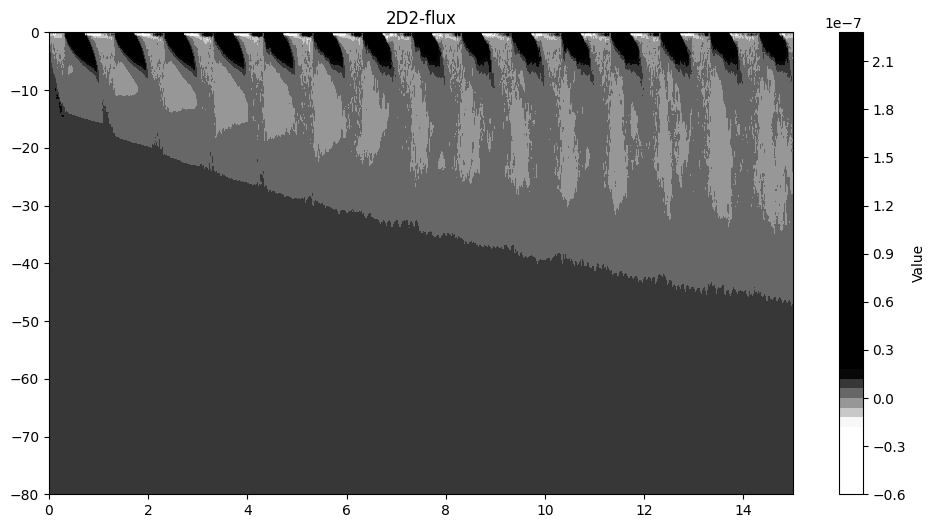

2D2


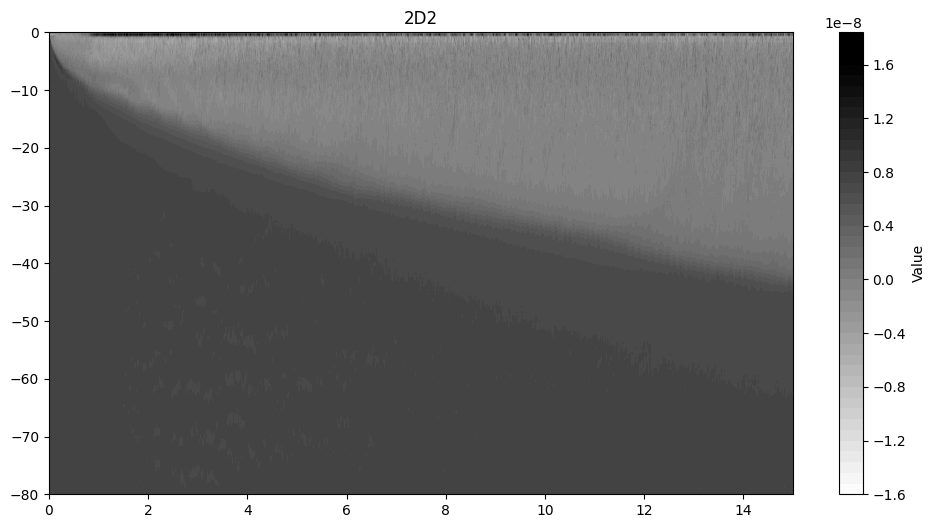

In [105]:
ds_avg = ds_avg_flux
data_set = case_flux
ds_q_avg = ds_avg.fbdz + ds_avg["ζb′"] - ds_avg.M2mvtdz 

plt.figure(figsize=(12, 6))

contourf = plt.contourf(ds_q_avg.coords["time"].values / np.timedelta64(1, 'D') , ds_q_avg.coords["zF"].values, ds_q_avg.T, levels=50, cmap='gray_r', vmin=-1.6e-8, vmax=1.6e-8)
plt.colorbar(contourf, label='Value')

# time_values = ds_q_avg.coords["time"].values / np.timedelta64(1, 'D')  # Convert time to days
# predicted_depth = predicted_PV_depth(time_values, i)
# plt.plot(time_values, -1 * predicted_depth, color='red', label='Predicted PV Depth')

plt.ylim(-80,0)
plt.xlim(0,15)
plt.title(f"{data_set}")
plt.savefig(f"images/{image_save_folder}{figure_name}.png", dpi=300, bbox_inches='tight')
plt.show()



ds_avg = ds_avg_noflux
data_set = case
print(data_set)
ds_q_avg = ds_avg.fbdz + ds_avg["ζb′"] - ds_avg.M2mvtdz 

plt.figure(figsize=(12, 6))
contourf = plt.contourf(ds_q_avg.coords["time"].values / np.timedelta64(1, 'D') , ds_q_avg.coords["zF"].values, ds_q_avg.T, levels=50, cmap='gray_r', vmin=-1.6e-8, vmax=1.6e-8)
plt.colorbar(contourf, label='Value')

# time_values = ds_q_avg.coords["time"].values / np.timedelta64(1, 'D')  # Convert time to days
# predicted_depth = predicted_PV_depth(time_values, i)
# plt.plot(time_values, -1 * predicted_depth, color='red', label='Predicted PV Depth')

plt.ylim(-80,0)
plt.xlim(0,15)
plt.title(f"{data_set}")
plt.savefig(f"images/{image_save_folder}{figure_name}.png", dpi=300, bbox_inches='tight')
plt.show()

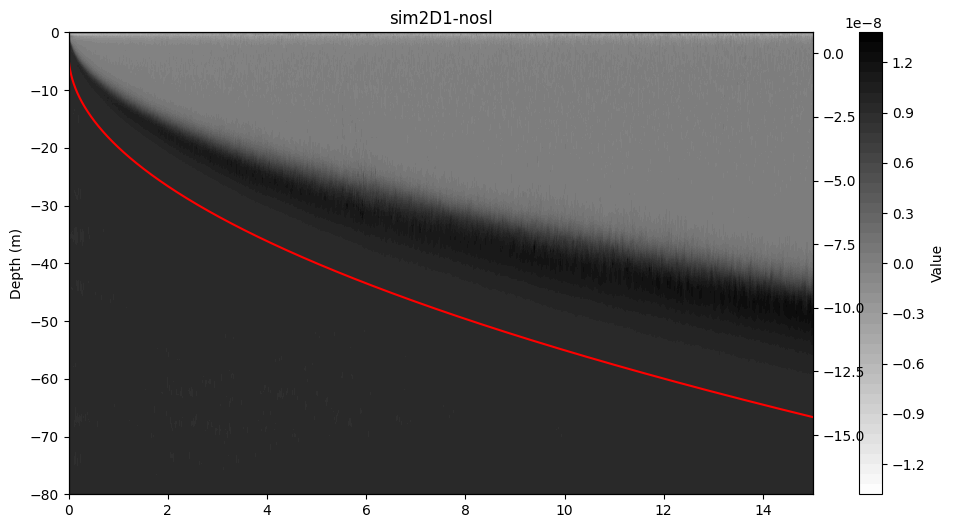

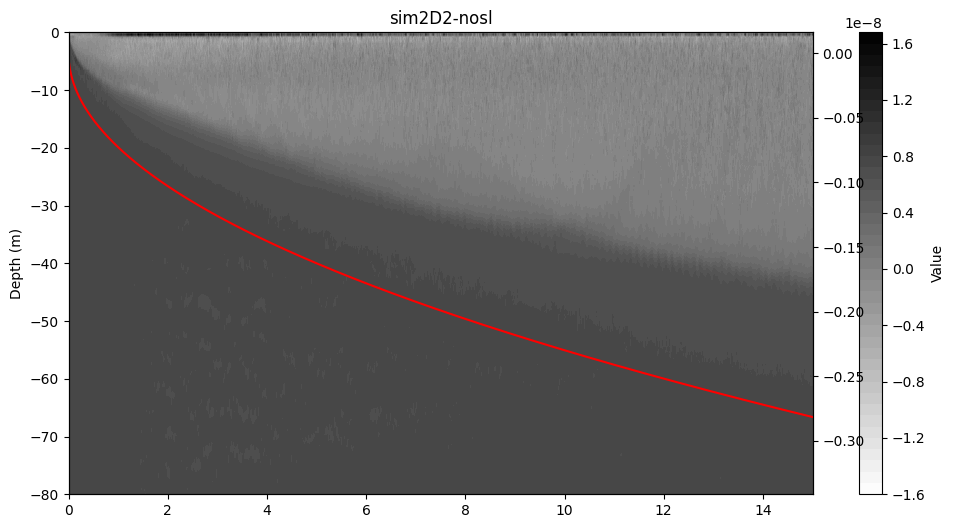

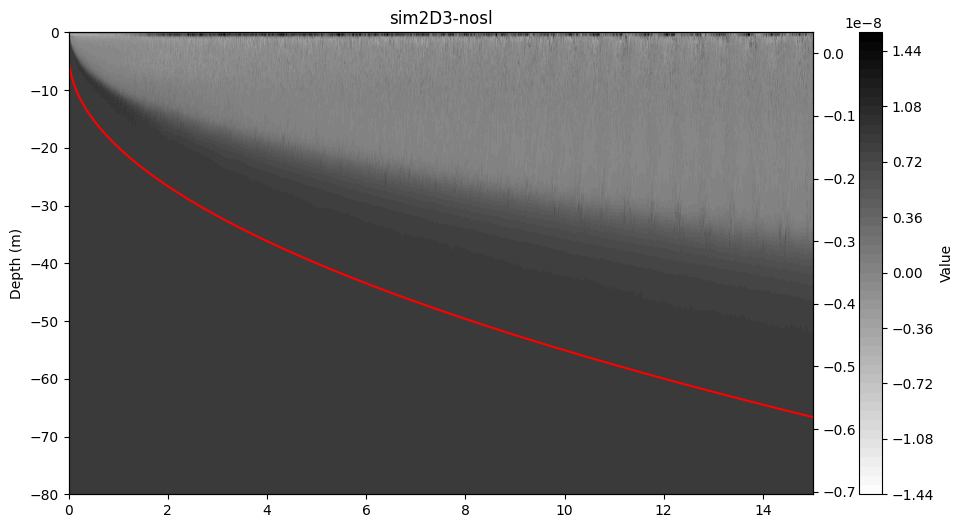

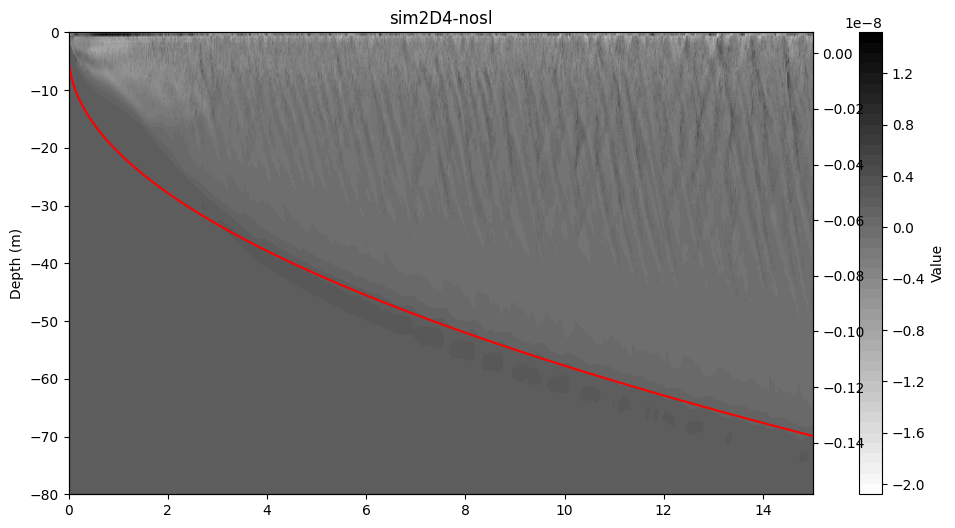

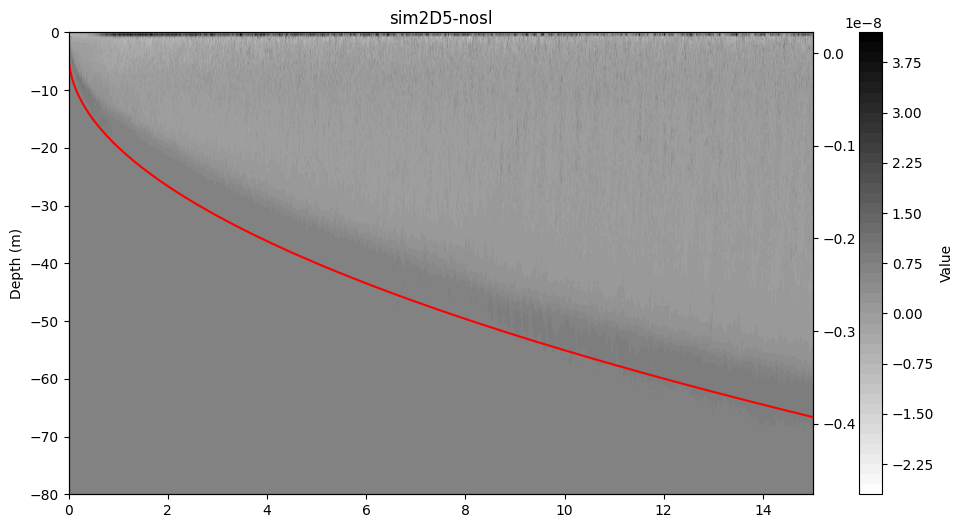

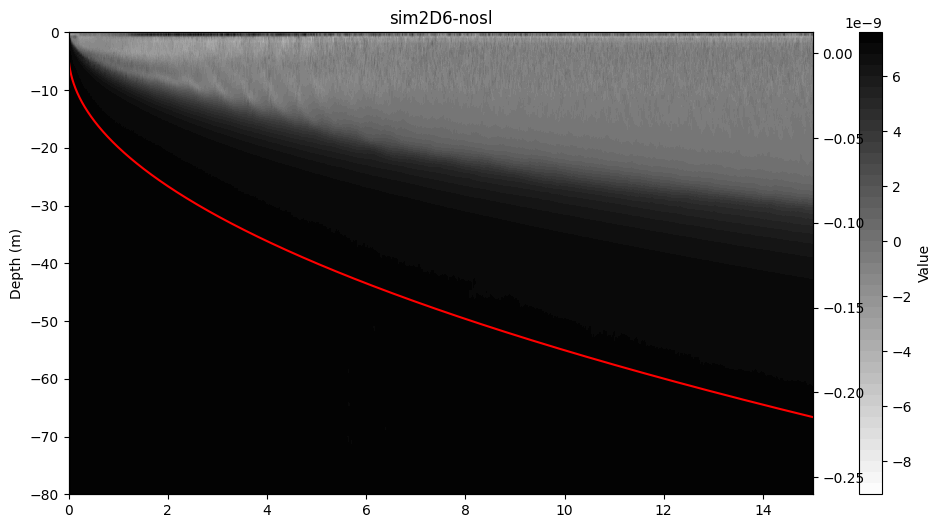

In [505]:
for i in num_simulations:
    ds_avg = ncs[i]
    data_set = cases[i]
    ds_q_avg = ds_avg.fbdz + ds_avg["ζb′"] - ds_avg.M2mvtdz 
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    contourf = ax1.contourf(ds_q_avg.coords["time"].values / np.timedelta64(1, 'D'), 
                            ds_q_avg.coords["zF"].values, 
                            ds_q_avg.T, 
                            levels=50, cmap='gray_r')
    ax1.set_ylabel('Depth (m)')
    ax1.set_ylim(-80, 0)
    ax1.set_xlim(0, 15)
    ax1.set_title(f"{data_set}")
    
    cbar = fig.colorbar(contourf, ax=ax1, label='Value')
    
    # Create a twin y-axis
    ax2 = ax1.twinx()
    
    time_values = ds_q_avg.coords["time"].values / np.timedelta64(1, 'D')  # Convert time to days
    predicted_depth = predicted_PV_depth(time_values, i)
    ax2.plot(time_values, -1 * predicted_depth, color='red', label='Predicted PV Depth')
    
    
    plt.show()

# Sponge Layer compared with no Sponge Layer

In [475]:
nc_file = f"../Data/sim2D2-20_averages.nc"
ds_avg1 = xr.open_dataset(nc_file).load()
ds_avg1.close()

nc_file = f"../Data/sim2D2-20-nosl_averages.nc"
ds_avg2 = xr.open_dataset(nc_file).load()
ds_avg2.close()

In [477]:
abs(ds_avg1.N2 - ds_avg2.N2).max().values

array(2.52251002e-05)